<a href="https://colab.research.google.com/github/schnekenberg/tcc-burned-area-detection/blob/main/03_eda_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **configurações do ambiente**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point

from google.colab import drive
drive.mount('/content/drive')

CSV_FOLDER = '/content/drive/MyDrive/CSV_files'
EDA_FOLDER = '/content/drive/MyDrive/EDA_files'

# carrega os .CSVs
train_df = pd.read_csv(f'{CSV_FOLDER}/train.csv')
val_df = pd.read_csv(f'{CSV_FOLDER}/val.csv')
test_df = pd.read_csv(f'{CSV_FOLDER}/test.csv')
df = pd.concat([train_df, val_df, test_df], ignore_index = True) # concatena .CSVs em uma única base para realizar análises

BANDS = ['B2', 'B3', 'B4', 'B8', 'B12', 'NDVI', 'NBR']
FEATURES = [f'{stat}_{b}' for stat in ['mean','std'] for b in BANDS]

print(f"Total de registros: {len(df)}")
print(f"Colunas: {list(df.columns)}")
print(f"\nCom fogo (1): {df['label'].sum()}")
print(f"Sem fogo (0): {(df['label'] == 0).sum()}")
print(f"Dentro de TI: {df['is_indigenous'].sum()}")

Mounted at /content/drive
Total de registros: 434440
Colunas: ['month', 'label', 'is_indigenous', 'tile_row', 'tile_col', 'centroid_lon', 'centroid_lat', 'mean_B2', 'std_B2', 'mean_B3', 'std_B3', 'mean_B4', 'std_B4', 'mean_B8', 'std_B8', 'mean_B12', 'std_B12', 'mean_NDVI', 'std_NDVI', 'mean_NBR', 'std_NBR']

Com fogo (1): 63721
Sem fogo (0): 370719
Dentro de TI: 243713


# **1. balanceamento de classes**
identifica desbalanceamento que pode prejudicar a performance dos modelos LLM

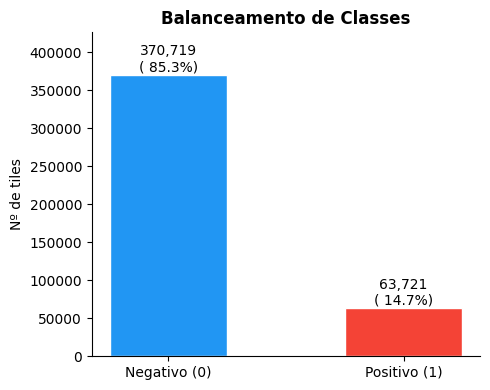

In [ ]:
# 1

fig, ax = plt.subplots(figsize = (5, 4))
counts = df['label'].value_counts().sort_index()
bars = ax.bar(['Negativo (0)', 'Positivo (1)'], counts.values,
              color = ['#2196F3','#F44336'], edgecolor = 'white', width = 0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f'{val:,}\n({val / len(df) * 100: .1f}%)',
            ha = 'center', va = 'bottom', fontsize = 10)
ax.set_title('Balanceamento de Classes', fontweight = 'bold')
ax.set_ylabel('Nº de tiles')
ax.set_ylim(0, counts.max() * 1.15)
sns.despine()
plt.tight_layout()
plt.savefig(f'{EDA_FOLDER}/eda_01_balanceamento.png', dpi = 150)
plt.show()

# **2. histogramas**
mostra sobreposição real entre classes nas features mais importantes para fogo

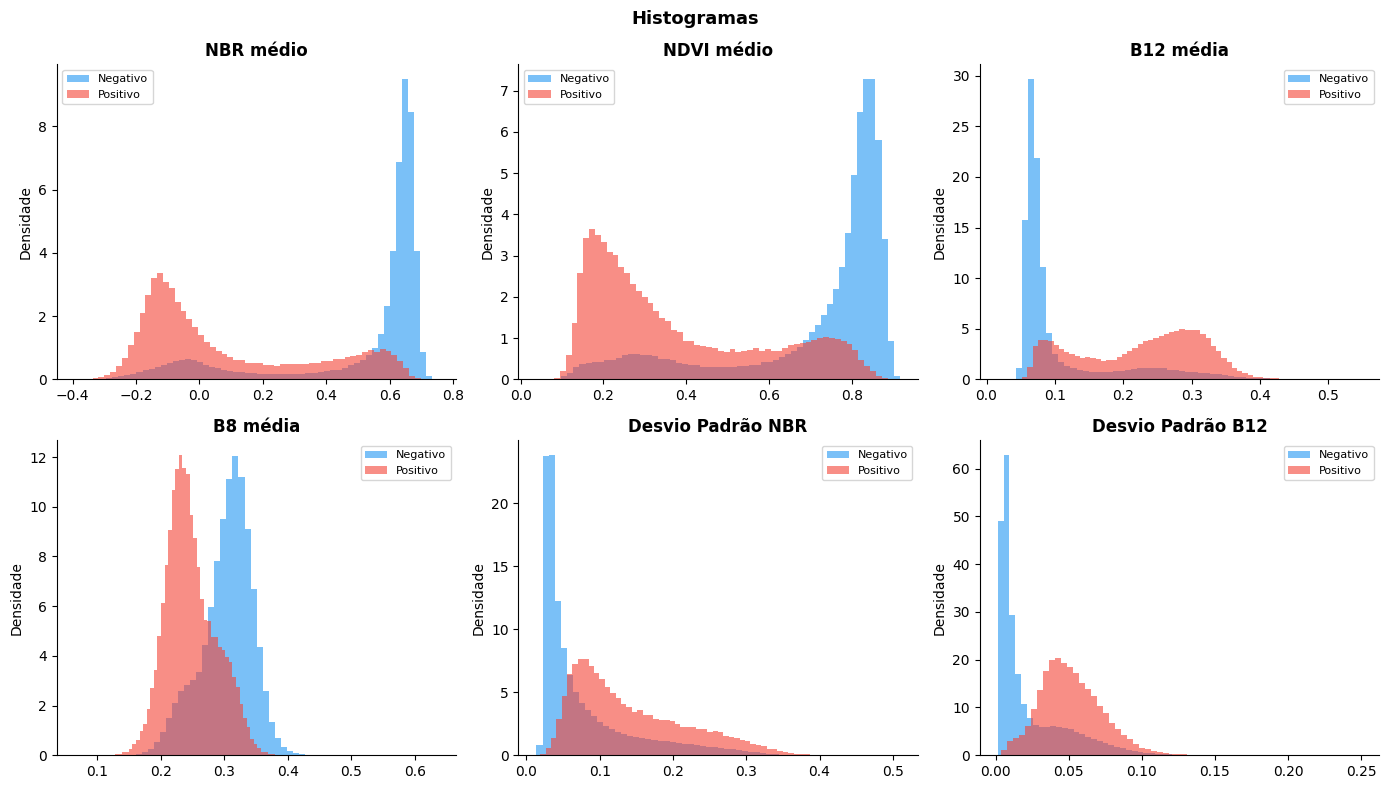

In [ ]:
# 2

feature_labels = {
    'mean_NBR': 'NBR médio',
    'mean_NDVI': 'NDVI médio',
    'mean_B12': 'B12 média',
    'mean_B8': 'B8 média',
    'std_NBR': 'Desvio Padrão NBR',
    'std_B12': 'Desvio Padrão B12'
}

top_features = ['mean_NBR', 'mean_NDVI', 'mean_B12', 'mean_B8', 'std_NBR', 'std_B12']
fig, axes = plt.subplots(2, 3, figsize = (14, 8))
axes = axes.flatten()
for i, feat in enumerate(top_features):
    ax = axes[i]
    ax.hist(df[df['label'] == 0][feat], bins = 60, alpha = 0.6,
            color = '#2196F3', label = 'Negativo', density = True)
    ax.hist(df[df['label'] == 1][feat], bins = 60, alpha = 0.6,
            color = '#F44336', label = 'Positivo', density = True)
    ax.set_title(feature_labels[feat], fontweight = 'bold')
    ax.set_ylabel('Densidade')
    ax.legend(fontsize = 8)
    sns.despine(ax = ax)
fig.suptitle('Histogramas', fontweight = 'bold', fontsize = 13)
plt.tight_layout()
plt.savefig(f'{EDA_FOLDER}/eda_02_histogramas.png', dpi = 150)
plt.show()

# **3. proporção de fogo em terras indígenas (TIs)**


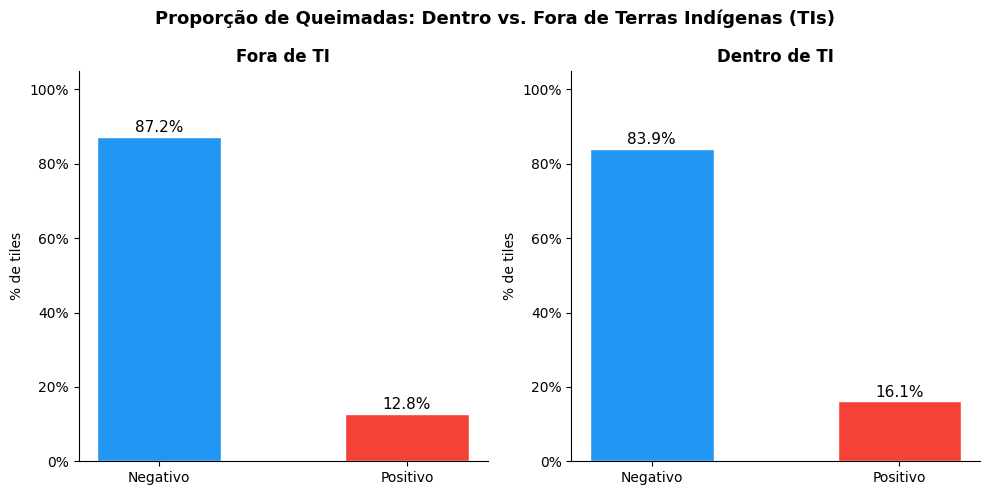

In [ ]:
# 3

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, (grupo, label_grupo) in zip(axes, [(0,'Fora de TI'), (1,'Dentro de TI')]):
    subset = df[df['is_indigenous'] == grupo]
    counts = subset['label'].value_counts().sort_index()
    pcts   = counts / counts.sum() * 100
    bars = ax.bar(['Negativo','Positivo'], pcts.values,
                  color=['#2196F3','#F44336'], edgecolor='white', width=0.5)
    for bar, pct in zip(bars, pcts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=11)
    ax.set_title(label_grupo, fontweight='bold')
    ax.set_ylabel('% de tiles')
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    sns.despine(ax=ax)
fig.suptitle('Proporção de Queimadas: Dentro vs. Fora de Terras Indígenas (TIs)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f'{EDA_FOLDER}/eda_03_ti_fogo.png', dpi=150)
plt.show()

# **4. distribuição geográfica do fogo**

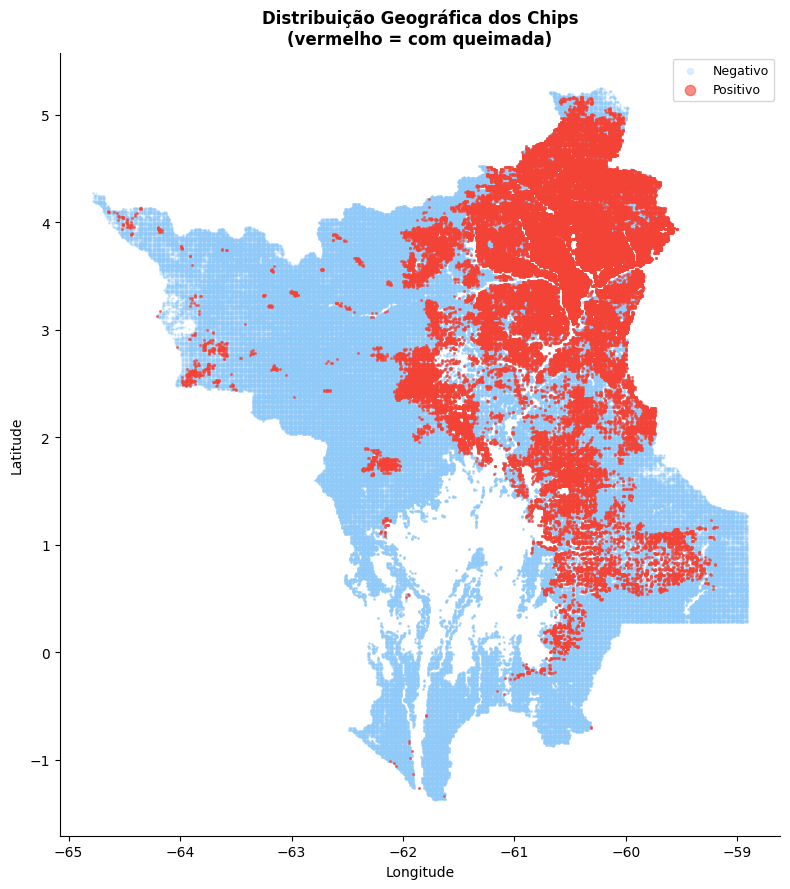

In [ ]:
# 4

fig, ax = plt.subplots(figsize = (8, 9))
sem_fogo = df[df['label'] == 0]
com_fogo = df[df['label'] == 1]
ax.scatter(sem_fogo['centroid_lon'], sem_fogo['centroid_lat'],
           c = '#90CAF9', s = 0.5, alpha = 0.3, label = 'Negativo', rasterized = True)
ax.scatter(com_fogo['centroid_lon'], com_fogo['centroid_lat'],
           c = '#F44336', s = 1.5, alpha = 0.6, label = 'Positivo', rasterized = True)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Distribuição Geográfica dos Chips\n(vermelho = com queimada)',
             fontweight = 'bold')
ax.legend(markerscale = 6, fontsize = 9)
sns.despine()
plt.tight_layout()
plt.savefig(f'{EDA_FOLDER}/eda_04_distribuicao_geografica.png', dpi = 150)
plt.show()

# **5. matriz de correlação**

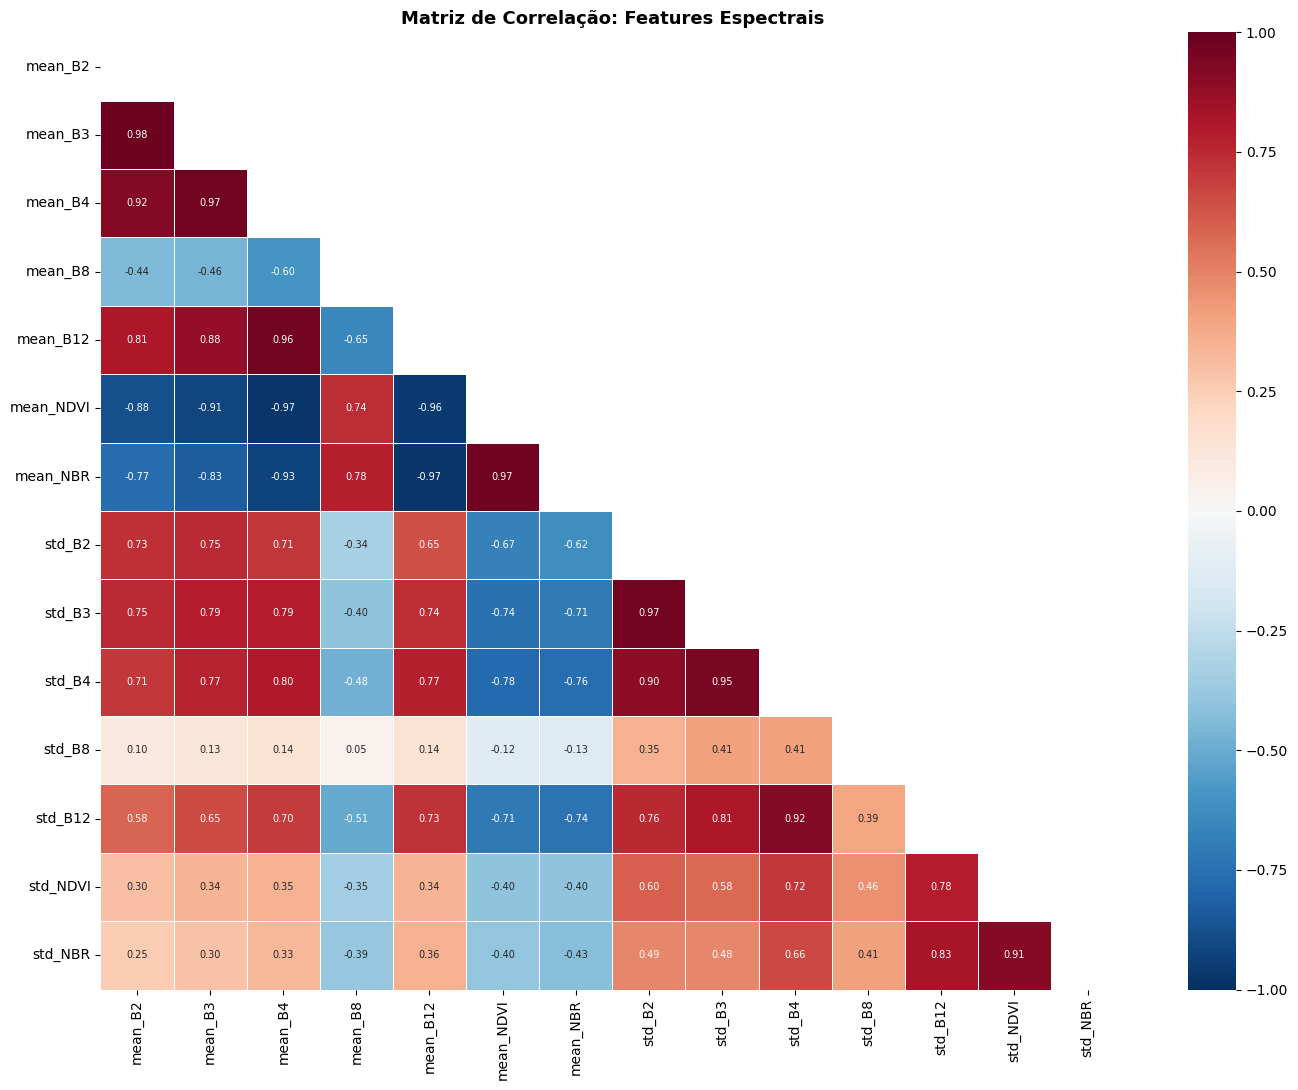

In [ ]:
# 5

fig, ax = plt.subplots(figsize = (14, 11))
corr = df[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype = bool))
sns.heatmap(corr, mask = mask, annot = True, fmt = '.2f', center = 0,
            cmap = 'RdBu_r', linewidths = 0.5, annot_kws = {'size': 7},
            vmin = -1, vmax = 1, ax = ax)
ax.set_title('Matriz de Correlação: Features Espectrais',
             fontweight = 'bold', fontsize = 13)
plt.tight_layout()
plt.savefig(f'{EDA_FOLDER}/eda_05_matriz_correlacao.png', dpi = 150)
plt.show()

# **6. proporção de queimadas por mês**

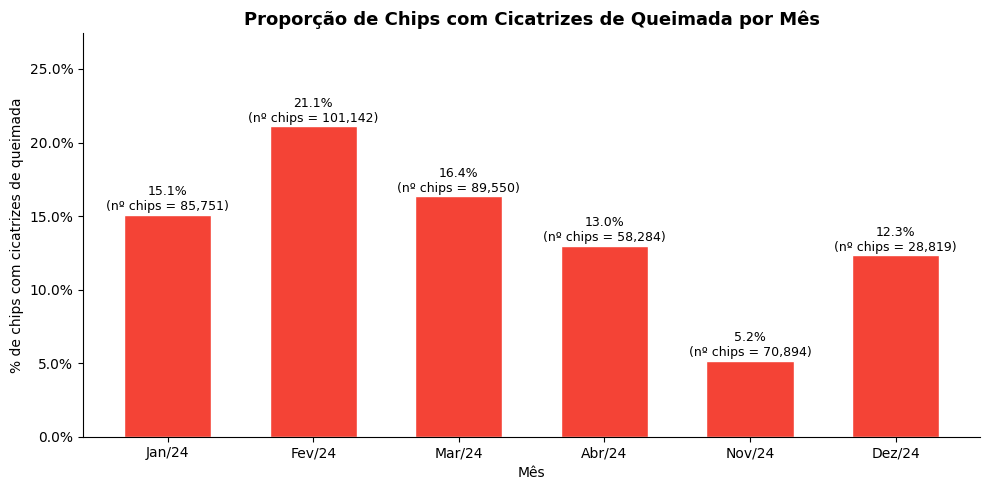

In [ ]:
# 6

fig, ax = plt.subplots(figsize=(10, 5))

month_stats = df.groupby('month')['label'].agg(
    total = 'count',
    queimadas = 'sum'
).reset_index()
month_stats['proporcao'] = month_stats['queimadas'] / month_stats['total'] * 100

month_labels = {
    '202401': 'Jan/24', '202402': 'Fev/24',
    '202403': 'Mar/24', '202404': 'Abr/24',
    '202411': 'Nov/24', '202412': 'Dez/24'
}
month_stats['mes_label'] = month_stats['month'].astype(str).map(month_labels)

bars = ax.bar(month_stats['mes_label'], month_stats['proporcao'],
              color = '#F44336', edgecolor = 'white', width = 0.6)

for bar, pct, total in zip(bars, month_stats['proporcao'], month_stats['total']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{pct:.1f}%\n(nº chips = {total:,})',
            ha = 'center', va = 'bottom', fontsize = 9)

ax.set_title('Proporção de Chips com Cicatrizes de Queimada por Mês',
             fontweight = 'bold', fontsize = 13)
ax.set_xlabel('Mês')
ax.set_ylabel('% de chips com cicatrizes de queimada')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylim(0, month_stats['proporcao'].max() * 1.3)
sns.despine()
plt.tight_layout()
plt.savefig(f'{EDA_FOLDER}/eda_06_queimadas_por_mes.png', dpi = 150)
plt.show()